In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
df = pd.read_csv("WineQuality.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5.0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5.0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6.0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0


In [5]:
df.shape

(1699, 12)

In [6]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5.0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5.0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6.0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1699 entries, 0 to 1698
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1699 non-null   float64
 1   volatile acidity      1699 non-null   float64
 2   citric acid           1699 non-null   float64
 3   residual sugar        1699 non-null   float64
 4   chlorides             1699 non-null   float64
 5   free sulfur dioxide   1699 non-null   float64
 6   total sulfur dioxide  1699 non-null   float64
 7   density               1699 non-null   float64
 8   pH                    1699 non-null   float64
 9   sulphates             1699 non-null   float64
 10  alcohol               1699 non-null   float64
 11  quality               1699 non-null   float64
dtypes: float64(12)
memory usage: 159.4 KB


In [8]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [9]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000
mean,8.329397,0.526786,0.271403,2.549096,0.087544,16.048253,46.897874,0.996747,3.311263,0.657206,10.421607,5.638028
std,1.726301,0.178695,0.194009,1.399910,0.046900,10.490591,32.733365,0.001887,0.154309,0.169189,1.066080,0.809308
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.094784,1.900000,0.070000,8.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.091000,22.000000,63.000000,0.997860,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


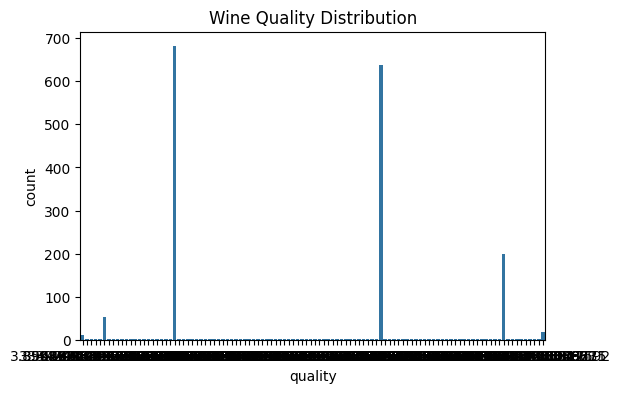

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x="quality", data=df)
plt.title("Wine Quality Distribution")
plt.show()

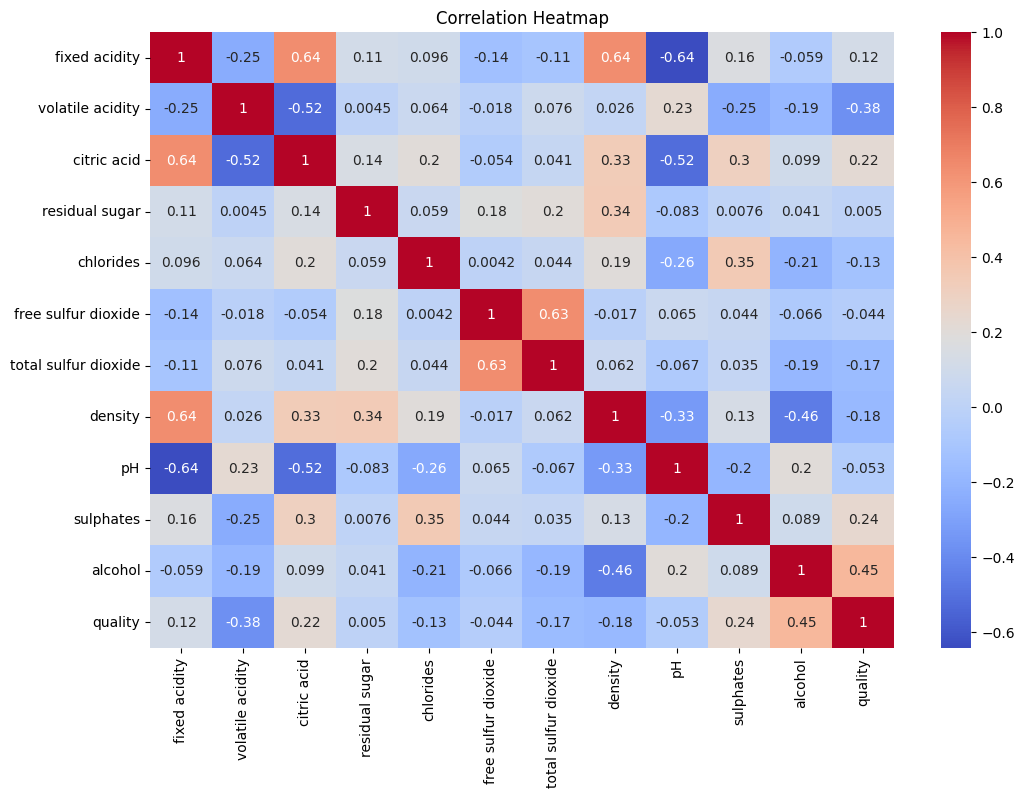

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [12]:
df["quality"] = df["quality"].apply(lambda x: 1 if x >= 7 else 0)

df["quality"].value_counts()

quality
0    1474
1     225
Name: count, dtype: int64

In [13]:
X = df.drop("quality", axis=1)
y = df["quality"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8911764705882353


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       296
           1       0.63      0.39      0.48        44

    accuracy                           0.89       340
   macro avg       0.77      0.68      0.71       340
weighted avg       0.88      0.89      0.88       340



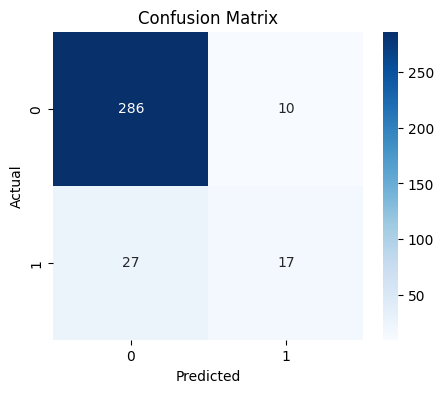

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

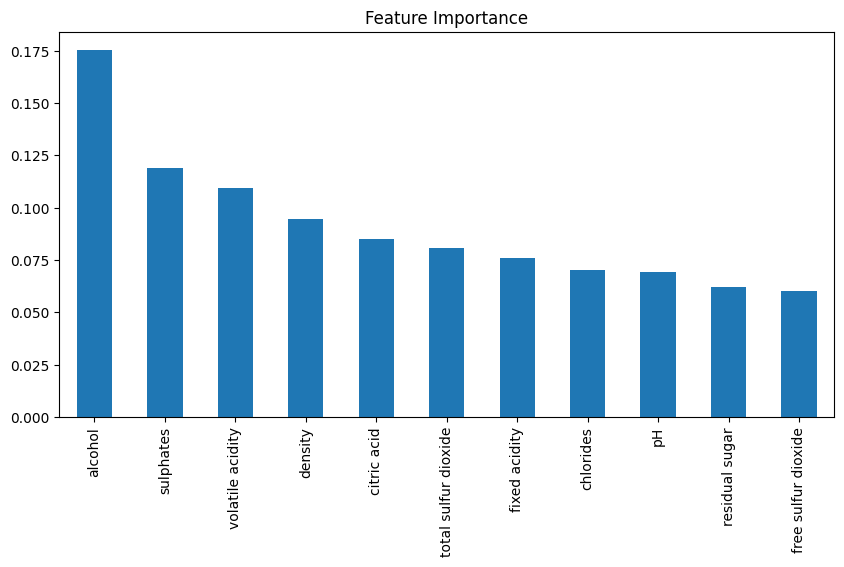

In [19]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind="bar", figsize=(10,5))
plt.title("Feature Importance")
plt.show()

# Conclusion

## Wine Quality Prediction Summary

- Loaded and explored the Wine Quality dataset.
- Performed data preprocessing and feature engineering.
- Trained a Random Forest classifier.
- Evaluated the model using Accuracy, Classification Report, and Confusion Matrix.
- Analyzed feature importance to identify the most influential factors affecting wine quality.

### Business Impact

This model can help wine producers predict wine quality and improve quality control based on chemical properties.

In [20]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(random_state=42)
sgd.fit(X_train, y_train)

y_pred_sgd = sgd.predict(X_test)

print("SGD Accuracy:", accuracy_score(y_test, y_pred_sgd))
print(classification_report(y_test, y_pred_sgd))

SGD Accuracy: 0.8735294117647059
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       296
           1       0.53      0.20      0.30        44

    accuracy                           0.87       340
   macro avg       0.71      0.59      0.61       340
weighted avg       0.84      0.87      0.85       340



In [22]:
from sklearn.svm import SVC

svc = SVC(random_state=42)
svc.fit(X_train, y_train)

y_pred_svc = svc.predict(X_test)

print("SVC Accuracy:", accuracy_score(y_test, y_pred_svc))

SVC Accuracy: 0.8705882352941177


In [23]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "SGD", "SVC"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_sgd),
        accuracy_score(y_test, y_pred_svc)
    ]
})

comparison

,Model,Accuracy
0,Random Forest,0.891176
1,SGD,0.873529
2,SVC,0.870588


# Final Conclusion

- Performed Exploratory Data Analysis (EDA).
- Checked class distribution.
- Trained three machine learning models:
  - Random Forest
  - SGD Classifier
  - Support Vector Classifier (SVC)
- Compared model performance using Accuracy, Classification Report, and Confusion Matrix.
- Random Forest achieved the best performance and is the most suitable model for wine quality prediction.